In [55]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import scipy.optimize as optimize
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa as tsa
import statsmodels.graphics as sm_graph

## Dicionario

| Dado | Desc |
| -----| -----|
| cdi | O cdi, neste caso mensal, em porcentagem.|
| taxa selic | taxa selic over em porcentagem |
| igpm | porcentagem da igp-m |
| ipca | variação mensal do ipca em porcentagem |

Não sinalizo isso no DataFrame porque fica mais facil digitar "cdi" do que digitar "cdi (%)".

In [4]:
df = pd.read_csv('out2.csv')
df.columns = ['inutil', 'mes', 'cdi', 'taxa selic', 'igpm', 'ipca']
df = df.drop('inutil', axis=1)
df = df.set_index('mes')

,cdi,taxa selic,igpm,ipca
mes,,,,
2023-01-01,1.1233,1.12,0.21,0.53
2023-02-01,0.9181,0.92,-0.06,0.84
2023-03-01,1.1747,1.17,0.05,0.71
2023-04-01,0.9181,0.92,-0.95,0.61
2023-05-01,1.1233,1.12,-1.84,0.23
2023-06-01,1.0720,1.07,-1.93,-0.08


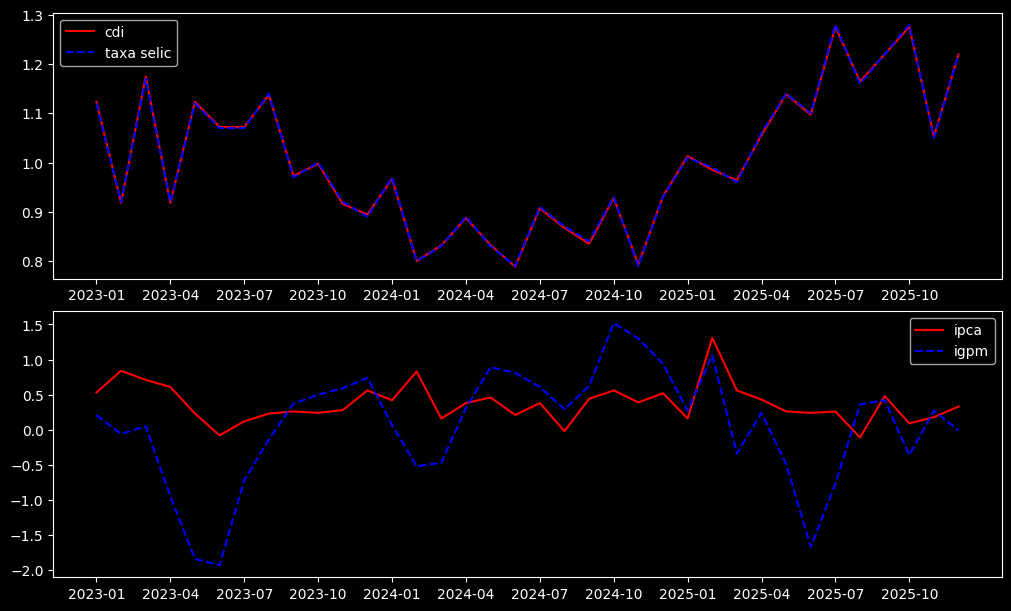

In [5]:
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, figsize=(10, 6), layout='constrained')

ax1.plot(df['cdi'], label='cdi', color='red')
ax1.plot(df['taxa selic'], label='taxa selic', color='blue', linestyle='--')
ax2.plot(df['ipca'], label='ipca', color='red')
ax2.plot(df['igpm'], label='igpm', color='blue', linestyle='--')

ax1.legend()
ax2.legend()
time = np.arange(df.index[0], df.index[-1], step=3,dtype='datetime64[M]')
_ = ax1.set_xticks(np.arange(0, 36, 3), labels=time)
_ = ax2.set_xticks(np.arange(0, 36, 3), labels=time)

## Modelando algumas coisas

Quanto ao CDI, esse talvez possa ser modelado como um processo estocastico de algum tipo. Depende da estacionariedade.

No caso eu poderia então simular um CDB com $\theta$ % do CDI, digamos 100%, por meio de
$$
V_t = V_0 \prod_{i=1}^t (1 + \theta R^{CDI}_i)
$$

No caso de um tesouro prefixado o calculo é simplesmente juros compostos dada uma taxa de $R_{pre}$, no caso uma taxa nominal.
A aleatoriedade vem da inflação, que nos gera então uma taxa de juros real:
$$
(1+r) = \frac{(1+R_{pre})}{(1+\alpha)}
$$
onde $\alpha$ denota a taxa de inflação.

## Índice de Sharpe
Se eu tiver uma carteira, e eu enumerar meus investimentos, então o indice sharpe do $i$-essimo investimento é:
$$
S_i = \frac{E[R_i] - R_f}{\sqrt{\text{Var}(R_i)}}
$$
onde $R_f$ é um investimento livre de risco (seja lá o que isso realmente signifique.)

Para renda fixa brasileira, o benchmark natural é o **CDI** (ou Selic). Portanto, para o CDB que **é** o CDI, o Sharpe seria zero por construção.

In [302]:
def bootstrap_iid(serie, n_sims, n_steps):
    # Sorteia índices com reposição
    boot = np.zeros((n_sims, n_steps+1))
    idx = np.random.randint(0, len(serie), size=(n_sims, n_steps))
    for row_idx, sim in enumerate(boot):
        boot[row_idx][1:] = serie.iloc[idx[row_idx]]   # shape (n_sim, n_steps)
    return boot

def tesouro_prefixado(taxa_pre):
    FCC = np.ones(13, dtype=float)
    for idx in range(len(FCC)):
        FCC[idx] = (1+taxa_pre)**(idx/12)
    return FCC

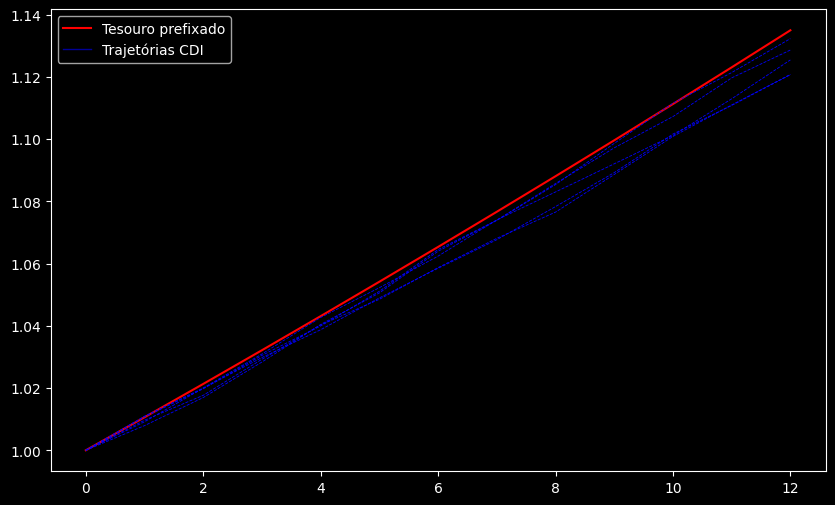

In [320]:
tesouro = tesouro_prefixado(13.5/100)
simulacoes_cdi = pd.DataFrame(bootstrap_iid(df['cdi'], 5, 12)).apply(lambda x: x/100 + 1, axis=0)

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(tesouro, label='Tesouro prefixado', color='red', linestyle='-')
_ = ax.plot(simulacoes_cdi.T.cumprod(), color='blue', linestyle='--', lw=0.6)
ax.plot([], [], color='blue', alpha=0.6, lw=1,label=f"Trajetórias CDI")
ax.legend()

# Analisando a serie temporal

Aqui considero um modelo do tipo OU/Vasicek:
$$
\mathrm{d}R_t = \kappa(\overline{R} - R_t) \mathrm{d}t + \omega \mathrm{d}W_t
$$

Que pode ser discretizado e nos dar um modelo do tipo AR(1):
$$
R_{t+1} = \kappa \overline{R} + R_t \cdot (1-\kappa) + \epsilon_t
$$

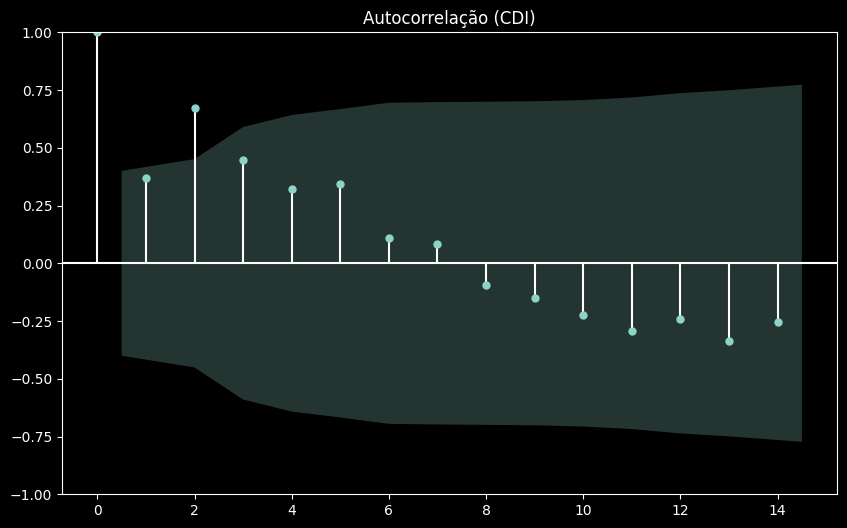

In [324]:
fig = sm_graph.tsaplots.plot_acf(df['2023':'2025']['cdi'], title=f'Autocorrelação (CDI)')
fig.set_figheight(6)
fig.set_figwidth(10)

In [87]:
model = sm.tsa.ARIMA(df['2023':'2025']['cdi'], order=(1,0,0), freq='MS')
res = model.fit()
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                    cdi   No. Observations:                   24
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  19.945
Date:                Sun, 15 Mar 2026   AIC                            -33.889
Time:                        03:39:54   BIC                            -30.355
Sample:                    01-01-2023   HQIC                           -32.952
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9496      0.038     24.772      0.000       0.874       1.025
ar.L1          0.3931      0.245      1.605      0.109      -0.087       0.873
sigma2         0.0110      0.004      2.589      0.0

/home/murasuu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


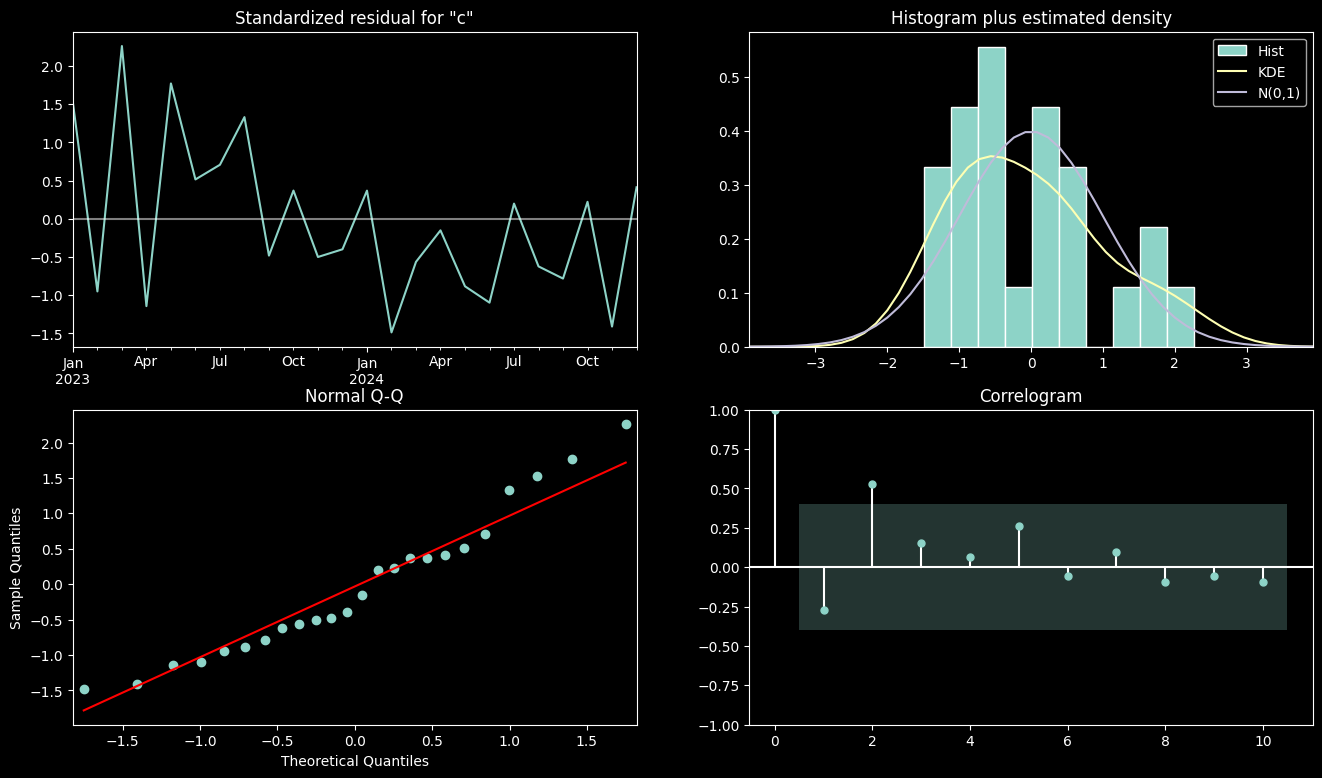

In [89]:
fig = plt.figure(figsize=(16, 9))
fig = res.plot_diagnostics(fig=fig)

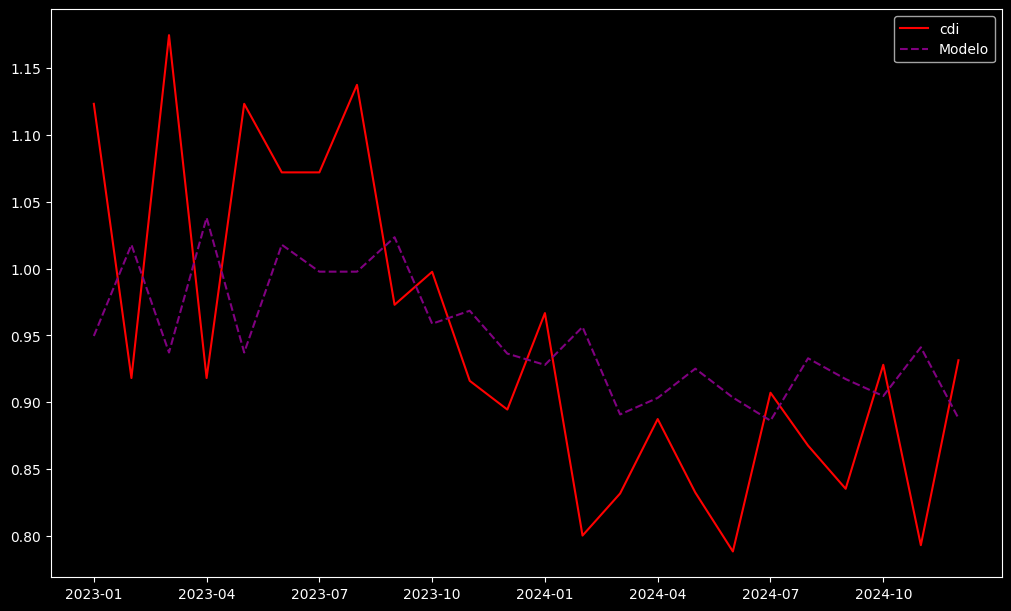

In [127]:
prediction = res.predict()
prediction = prediction.to_numpy()

fig, ax = plt.subplots(figsize=(10,6), layout='constrained')

ax.plot(df['2023':'2025']['cdi'], label='cdi', color='red')
ax.plot(prediction, label='Modelo', color='purple', linestyle='--')
ax.legend()

time = np.arange(df['2023':'2025'].index[0], df['2023':'2025'].index[-1], step=3,dtype='datetime64[M]')
_ = ax.set_xticks(np.arange(0, 24, 3), labels=time)